# <i>CatBoost learning to rank on Microsoft dataset</i>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/catboost/tutorials/blob/master/ranking/ranking_tutorial.ipynb)

In [1]:
# %pip install catboost

In [2]:
from catboost import CatBoostRanker, Pool, MetricVisualizer
from copy import deepcopy
import numpy as np
import os
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

### Ranking problem

Let's introduce a notation:
* Let $Q = \{q_1, \dots, q_n\}$ be the set of groups
* $D_q = \{d_{q1}, \dots, d_{qm}\}$ -- set of objects retrieved for a group $q$
* $L_q = \{l_{q1}, \dots, l_{qm}\}$ -- relevance labels for the objects from the set $D_q$

Every object $d_{qi}$ is represented in the vector space of features, describing the associatinos between the group and the object.

So every group is associated with set of objects. For example, group is a query and object is a document if we are ranking documents for a search query.

The goal is to learn the ranking function $f = f(d_{qi})$, such that the ranking of objects $d_{qi}$ for all groups from $Q$ based on their scores $x_{qi} = f(d_{qi})$, is as close as possible to the ideal ranking from the editorial judgements $l_{qi}$.

### Download part of [MSRank](https://www.microsoft.com/en-us/research/project/mslr/) dataset from CatBoost datasets storage

In [4]:
from catboost.datasets import msrank_10k
train_df, test_df = msrank_10k()

X_train = train_df.drop([0, 1], axis=1).values
y_train = train_df[0].values
queries_train = train_df[1].values

X_test = test_df.drop([0, 1], axis=1).values
y_test = test_df[0].values
queries_test = test_df[1].values

### Dataset analysis

__Number of documents__

In [5]:
num_documents = X_train.shape[0]
print(num_documents)

10000


__Number of features__

In [6]:
X_train.shape[1]

136

__Relevance labels statistics__

0 - irrelevant, 1 - highly relevant. Table represents number of documents for each value.

In [7]:
from collections import Counter
Counter(y_train).items()

dict_items([(2.0, 1326), (0.0, 5481), (1.0, 3000), (3.0, 142), (4.0, 51)])

For calculation such metrics as NDCG and PFound relevances should be in segment \[0,1\].

In [8]:
max_relevance = np.max(y_train)
y_train /= max_relevance
y_test /= max_relevance

__Number of queries__

In [9]:
num_queries = np.unique(queries_train).shape[0]
num_queries

87

### Creation of CatBoost pools

In [10]:
train = Pool(
    data=X_train,
    label=y_train,
    group_id=queries_train
)

test = Pool(
    data=X_test,
    label=y_test,
    group_id=queries_test
)

### You can also create pools from files

In [11]:
data_dir = './msrank'

if not os.path.exists(data_dir):
    os.makedirs(data_dir)

train_file = os.path.join(data_dir, 'train.csv')
test_file = os.path.join(data_dir, 'test.csv')

train_df.to_csv(train_file, index=False, header=False)
test_df.to_csv(test_file, index=False, header=False)

In [12]:
description_file = os.path.join(data_dir, 'dataset.cd')
with open(description_file, 'w') as f:
    f.write('0\tLabel\n')
    f.write('1\tQueryId\n')

In [13]:
Pool(data=train_file, column_description=description_file, delimiter=',')

### <span style="color:#ce2029">Attention:</span> all objects in dataset must be grouped by group_id

For example, if the dataset consits of five documents 
\[d1, d2, d3, d4, d5\] with corresponding queries \[q1, q2, q2, q1, q2\] then the dataset should be look like:

$$\begin{pmatrix}
    d_1, q_1, f_1\\
    d_4, q_1, f_4\\
    d_2, q_2, f_2\\
    d_3, q_2, f_3\\
    d_5, q_2, f_5\\
\end{pmatrix} \hspace{6px} \texttt{or} \hspace{6px}
\begin{pmatrix}
    d_2, q_2, f_2\\
    d_3, q_2, f_3\\
    d_5, q_2, f_5\\
    d_1, q_1, f_1\\
    d_4, q_1, f_4\\
\end{pmatrix}$$

where $f_i$ is feature vector of i-th document.

### Reducing problem to machine learning task

The first and simplest idea is to try predicting document relevance $l_q$ minimizing RMSE.

$$\frac{1}{N}\sqrt{ \sum_q \sum_{d_{qk}} \left(f(d_{qk}) - l_{qk} \right)^2 }$$

In [14]:
default_parameters = {
    'iterations': 2000,
    'custom_metric': ['NDCG', 'PFound', 'AverageGain:top=10'],
    'verbose': False,
    'random_seed': 0,
}

parameters = {}

In [15]:
def fit_model(loss_function, additional_params=None, train_pool=train, test_pool=test):
    parameters = deepcopy(default_parameters)
    parameters['loss_function'] = loss_function
    parameters['train_dir'] = loss_function

    if additional_params is not None:
        parameters.update(additional_params)

    model = CatBoostRanker(**parameters)
    model.fit(
        train_pool, 
        eval_set=test_pool, 
        plot=False, # убрал график
        verbose=100
    )

    return model

#### К сожалению, у меня не прогрузились динамические графики ни в VSCode, ни в colab (в колабе я съел всю квоту), поэтому использую mpl, чтобы получить хотя бы статические

In [16]:
def plot_metrics(model, metrics=None):
    results = model.get_evals_result()

    if metrics is None:
        metrics = list(results.get('learn', {}).keys())

    _, axes = plt.subplots(len(metrics), 1, figsize=(10, 4 * len(metrics)))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        if 'learn' in results and metric in results['learn']:
            ax.plot(results['learn'][metric], label='Train')
        if 'validation' in results and metric in results['validation']:
            ax.plot(results['validation'][metric], label='Validation')
        ax.set_title(metric)
        ax.set_xlabel('Iteration')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

Lets train the simplest model and also demonstrate precision/recall metrics from introduction.

c:\Users\ASUS\.pyenv\pyenv-win\versions\3.11.4\Lib\site-packages\catboost\core.py:6705: RuntimeWarning: Regression loss ('RMSE') ignores an important ranking parameter 'group_id'
  warnings.warn("Regression loss ('{}') ignores an important ranking parameter 'group_id'".format(loss_function), RuntimeWarning)


Learning rate set to 0.047893
0:	learn: 0.1996578	test: 0.1977411	best: 0.1977411 (0)	total: 147ms	remaining: 4m 54s
100:	learn: 0.1748569	test: 0.1833110	best: 0.1833110 (100)	total: 1.78s	remaining: 33.4s
200:	learn: 0.1681053	test: 0.1829329	best: 0.1828479 (149)	total: 3.04s	remaining: 27.3s
300:	learn: 0.1620526	test: 0.1829443	best: 0.1827505 (242)	total: 4.37s	remaining: 24.7s
400:	learn: 0.1563746	test: 0.1831037	best: 0.1827505 (242)	total: 5.76s	remaining: 23s
500:	learn: 0.1512787	test: 0.1833131	best: 0.1827505 (242)	total: 7.24s	remaining: 21.7s
600:	learn: 0.1471450	test: 0.1836288	best: 0.1827505 (242)	total: 8.47s	remaining: 19.7s
700:	learn: 0.1431209	test: 0.1838442	best: 0.1827505 (242)	total: 9.8s	remaining: 18.2s
800:	learn: 0.1392301	test: 0.1841147	best: 0.1827505 (242)	total: 11.3s	remaining: 16.9s
900:	learn: 0.1356028	test: 0.1841529	best: 0.1827505 (242)	total: 13.5s	remaining: 16.5s
1000:	learn: 0.1320820	test: 0.1844328	best: 0.1827505 (242)	total: 15s	rema

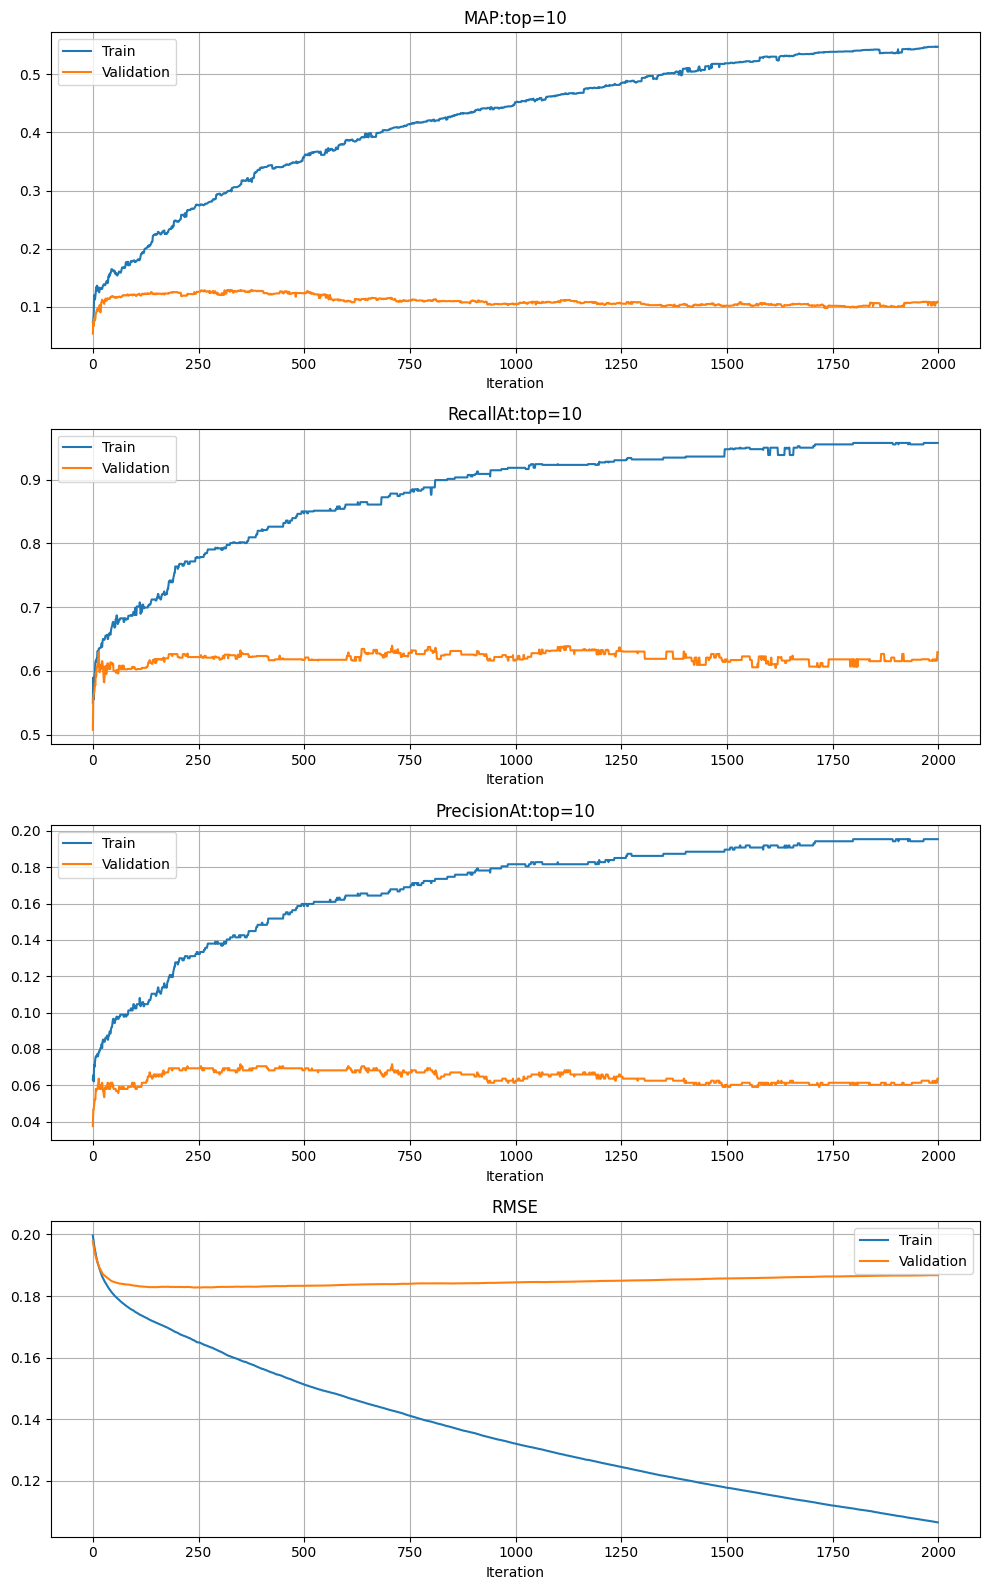

In [17]:
model = fit_model('RMSE', {'custom_metric': ['PrecisionAt:top=10', 'RecallAt:top=10', 'MAP:top=10']})
plot_metrics(model)

Модель переобучилась уже к 300 итерации. Но ничего страшного -- катбуст задетектировал переобучение и вовремя остановился.

### Group weights parameter
Suppose we know that some queries are more important than others for us.<br/>
The word "importance" used here in terms of accuracy or quality of CatBoostRanker prediction for given queries.<br/>
You can pass this additional information for learner using a ``group_weights`` parameter.<br/>
Under the hood, CatBoostRanker uses this weights in loss function simply multiplying it on a group summand.<br/>
So the bigger weight $\rightarrow$ the more attention for query.<br/>
Let's show an example of training procedure with random query weights.

Learning rate set to 0.047893
0:	learn: 0.2007218	test: 0.1981749	best: 0.1981749 (0)	total: 33.9ms	remaining: 1m 7s
100:	learn: 0.1728171	test: 0.1839859	best: 0.1839266 (96)	total: 1.49s	remaining: 28.1s
200:	learn: 0.1638168	test: 0.1836963	best: 0.1834123 (136)	total: 2.92s	remaining: 26.1s
300:	learn: 0.1569964	test: 0.1837631	best: 0.1834123 (136)	total: 4.38s	remaining: 24.7s
400:	learn: 0.1510962	test: 0.1842615	best: 0.1834123 (136)	total: 5.77s	remaining: 23s
500:	learn: 0.1462403	test: 0.1845336	best: 0.1834123 (136)	total: 7.11s	remaining: 21.3s
600:	learn: 0.1413560	test: 0.1848876	best: 0.1834123 (136)	total: 8.67s	remaining: 20.2s
700:	learn: 0.1363603	test: 0.1851029	best: 0.1834123 (136)	total: 9.96s	remaining: 18.5s
800:	learn: 0.1321018	test: 0.1853588	best: 0.1834123 (136)	total: 11.4s	remaining: 17.1s
900:	learn: 0.1282999	test: 0.1858521	best: 0.1834123 (136)	total: 12.8s	remaining: 15.6s
1000:	learn: 0.1245771	test: 0.1862243	best: 0.1834123 (136)	total: 14.2s	re

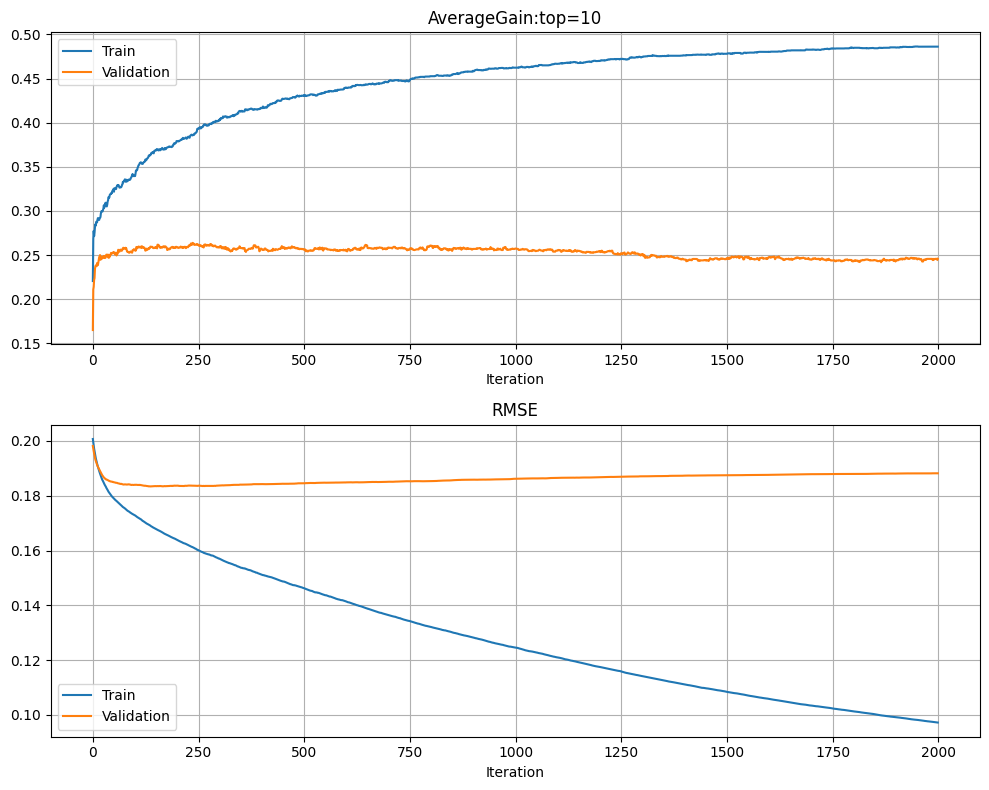

In [18]:
def create_weights(queries):
    query_set = np.unique(queries)
    query_weights = np.random.uniform(size=query_set.shape[0])
    weights = np.zeros(shape=queries.shape)

    for i, query_id in enumerate(query_set):
        weights[queries == query_id] = query_weights[i]

    return weights


train_with_weights = Pool(
    data=X_train,
    label=y_train,
    group_weight=create_weights(queries_train),
    group_id=queries_train
)

test_with_weights = Pool(
    data=X_test,
    label=y_test,
    group_weight=create_weights(queries_test),
    group_id=queries_test
)

model_with_grouped_weights = fit_model(
    'RMSE',
    additional_params={'train_dir': 'RMSE_weigths'},
    train_pool=train_with_weights,
    test_pool=test_with_weights
)
plot_metrics(model_with_grouped_weights)

### A special case: top-1 prediction

Someday you may face with a problem $-$ you will need to predict the top one most relevant object for a given query.<br/>
For this purpose CatBoostRanker has a mode called __QuerySoftMax__.

Suppose our dataset contain a binary target: 1 $-$ mean best document for a query, 0 $-$ others.<br/>
We will maximize the probability of being the best document for given query.<br/>
MSRANK dataset doesn't contain binary labels, but for example of method __QuerySoftMax__ we convert it to that format,<br/> choosing a best document for every query.

In [19]:
def get_best_documents(labels, queries):
    query_set = np.unique(queries)
    num_queries = query_set.shape[0]
    by_query_arg_max = {query: -1 for query in query_set}

    for i, query in enumerate(queries):
        best_idx = by_query_arg_max[query]
        if best_idx == -1 or labels[best_idx] < labels[i]:
            by_query_arg_max[query] = i

    binary_best_docs = np.zeros(shape=labels.shape)
    for arg_max in by_query_arg_max.values():
        binary_best_docs[arg_max] = 1.

    return binary_best_docs

0:	learn: 4.5291813	test: 4.5455258	best: 4.5455258 (0)	total: 42.3ms	remaining: 1m 24s
100:	learn: 2.7160321	test: 4.3293108	best: 4.3293108 (100)	total: 3.43s	remaining: 1m 4s
200:	learn: 1.8587595	test: 4.2824980	best: 4.2808075 (195)	total: 6.76s	remaining: 1m
300:	learn: 1.3697864	test: 4.2466412	best: 4.2466412 (300)	total: 10.3s	remaining: 58.2s
400:	learn: 1.0052353	test: 4.2322952	best: 4.2300564 (370)	total: 13.7s	remaining: 54.8s
500:	learn: 0.6994151	test: 4.2278589	best: 4.2260257 (496)	total: 17s	remaining: 50.9s
600:	learn: 0.4998069	test: 4.2195339	best: 4.2153837 (585)	total: 20.3s	remaining: 47.2s
700:	learn: 0.3801507	test: 4.2165605	best: 4.2153837 (585)	total: 23.6s	remaining: 43.6s
800:	learn: 0.2848394	test: 4.2068545	best: 4.2050824 (786)	total: 26.9s	remaining: 40.2s
900:	learn: 0.2132658	test: 4.2076864	best: 4.2029610 (816)	total: 30.4s	remaining: 37s
1000:	learn: 0.1638898	test: 4.2114153	best: 4.2029610 (816)	total: 34s	remaining: 34s
1100:	learn: 0.1340793

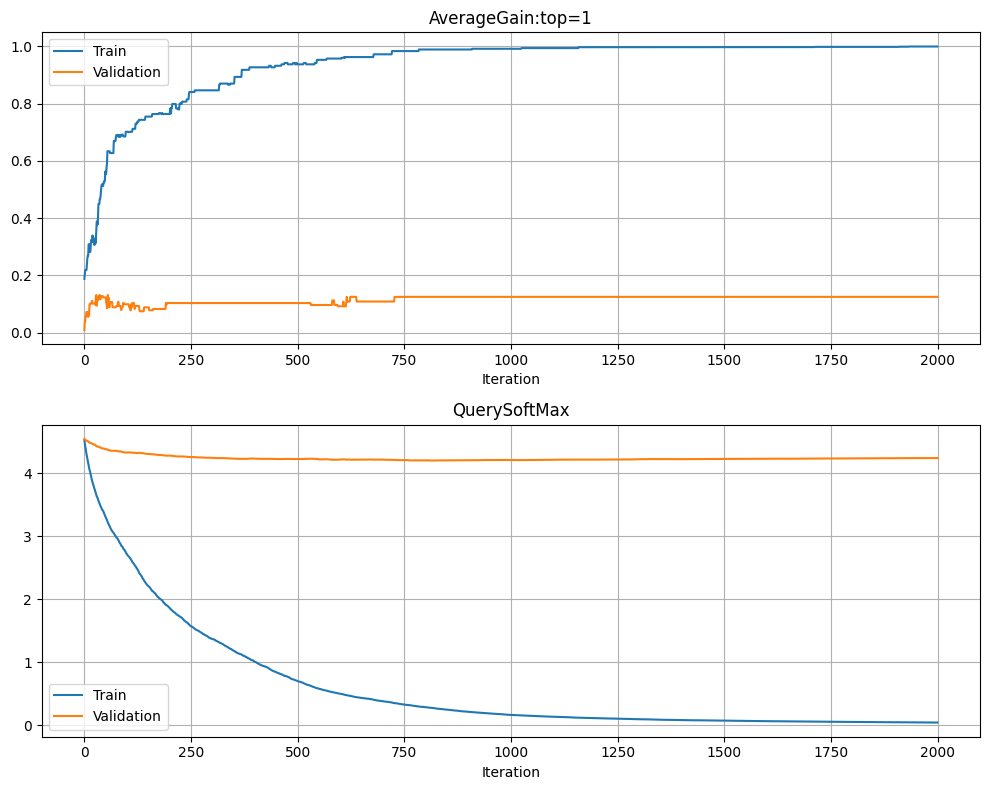

In [20]:
best_docs_train = get_best_documents(y_train, queries_train)
best_docs_test = get_best_documents(y_test, queries_test)

train_with_weights = Pool(
    data=X_train,
    label=best_docs_train,
    group_id=queries_train,
    group_weight=create_weights(queries_train)
)

test_with_weights = Pool(
    data=X_test,
    label=best_docs_test,
    group_id=queries_test,
    group_weight=create_weights(queries_test)
)

model_querysoftmax = fit_model(
    'QuerySoftMax',
    additional_params={'custom_metric': 'AverageGain:top=1'},
    train_pool=train_with_weights,
    test_pool=test_with_weights
)
plot_metrics(model_querysoftmax)

Бросается в глаза, что моделька учится дольше.
Также заметно, что.

### Reducing ploblem, step 2

Now lets look at example of documents relevance:

$$ 
    \begin{align}
    labels(q_1) &= \begin{bmatrix}
           4 \\
           3 \\
           3 \\
           1
         \end{bmatrix},
    labels(q_2) &= \begin{bmatrix}
           2 \\
           1 \\
           1 \\
           0
         \end{bmatrix}
   \end{align}
$$

This means that with RMSE loss function we pay more attention to q1 than q2. 

To avoid this problem we introduce into RMSE a coefficient $c_q$ which depends only on query (and if fact equals to the mean of the difference between prediction and label).

$$\frac{1}{N}\sqrt{ \sum_q \sum_{d_{qk}} \left(f(d_{qk}) - l_{qk} - \color{red}{c_{q}} \right)^2 }$$

0:	learn: 0.1913124	test: 0.1842455	best: 0.1842455 (0)	total: 12.5ms	remaining: 25s
100:	learn: 0.1752932	test: 0.1769228	best: 0.1769228 (100)	total: 1.5s	remaining: 28.3s
200:	learn: 0.1697477	test: 0.1757794	best: 0.1757794 (200)	total: 2.96s	remaining: 26.5s
300:	learn: 0.1658221	test: 0.1753826	best: 0.1753826 (300)	total: 4.26s	remaining: 24s
400:	learn: 0.1620817	test: 0.1750947	best: 0.1750947 (400)	total: 5.69s	remaining: 22.7s
500:	learn: 0.1589697	test: 0.1750736	best: 0.1750736 (500)	total: 7.86s	remaining: 23.5s
600:	learn: 0.1562137	test: 0.1752299	best: 0.1750735 (502)	total: 10s	remaining: 23.3s
700:	learn: 0.1530936	test: 0.1752620	best: 0.1750735 (502)	total: 12.2s	remaining: 22.6s
800:	learn: 0.1504690	test: 0.1753122	best: 0.1750735 (502)	total: 14.2s	remaining: 21.3s
900:	learn: 0.1476366	test: 0.1754596	best: 0.1750735 (502)	total: 16.4s	remaining: 20s
1000:	learn: 0.1448922	test: 0.1755582	best: 0.1750735 (502)	total: 18.3s	remaining: 18.2s
1100:	learn: 0.142425

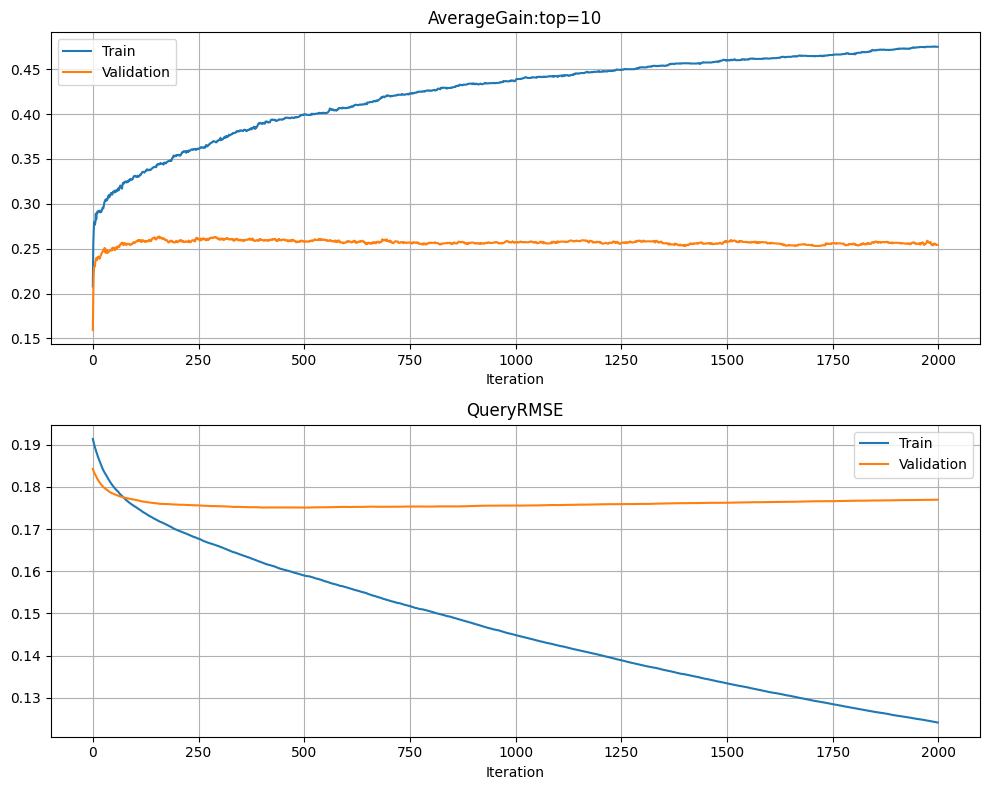

In [21]:
model_qrmse = fit_model('QueryRMSE')
plot_metrics(model_qrmse)

### Reducing problem, step 3

Since the goal of ranking is to predict a list of documents (which can be generated from given document relevances) RMSE loss function doesn't take into account relations between documents: the first is better than second, second is better than third and fifth etc.

We can easily bring this information into the loss function, reducing problem not to regression but classification for two documents $(d_i, d_j)$ -- does $i$th better than $j$th or not.

So we minimize the negative loglikelihood:

$$ - \sum_{i,j \in Pairs} \log \left( \frac{1}{1 + \exp{-(f(d_i) - f(d_j))}} \right) $$

Methods based on pair comparisons called __pairwise__ in CatBoostRanker this objective called __PairLogit__.

There's no need to change the dataset CatBoost generate the pairs for us. The number of generating pairs managed via parameter max_size.

0:	learn: 0.6913301	test: 0.6920109	best: 0.6920109 (0)	total: 210ms	remaining: 6m 59s
100:	learn: 0.6119626	test: 0.6530342	best: 0.6530067 (99)	total: 17.8s	remaining: 5m 35s
200:	learn: 0.5831140	test: 0.6488625	best: 0.6488086 (192)	total: 36.8s	remaining: 5m 29s
300:	learn: 0.5610864	test: 0.6473297	best: 0.6472810 (299)	total: 55.3s	remaining: 5m 11s
400:	learn: 0.5279680	test: 0.6395034	best: 0.6395034 (400)	total: 1m 14s	remaining: 4m 57s
500:	learn: 0.4727038	test: 0.6361675	best: 0.6352117 (468)	total: 1m 35s	remaining: 4m 44s
600:	learn: 0.4322862	test: 0.6391651	best: 0.6352117 (468)	total: 1m 54s	remaining: 4m 25s
700:	learn: 0.3990907	test: 0.6437604	best: 0.6352117 (468)	total: 2m 13s	remaining: 4m 7s
800:	learn: 0.3711766	test: 0.6462590	best: 0.6352117 (468)	total: 2m 32s	remaining: 3m 48s
900:	learn: 0.3458798	test: 0.6483208	best: 0.6352117 (468)	total: 2m 51s	remaining: 3m 29s
1000:	learn: 0.3227625	test: 0.6528162	best: 0.6352117 (468)	total: 3m 11s	remaining: 3m 1

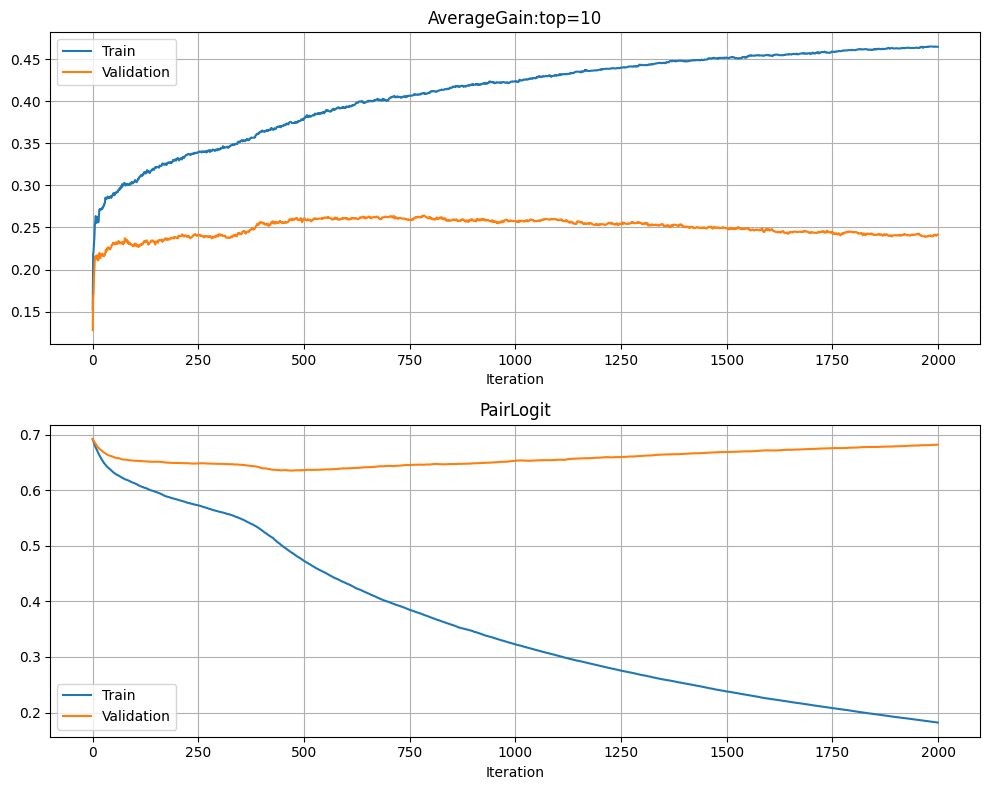

In [22]:
model_pairlogits = fit_model('PairLogit')
plot_metrics(model_pairlogits)

Also we can to specify the pairs directly. There are two ways to do that:

1. Two-dimensional matrix with shape=(num_pairs, 2) $\rightarrow$ (winner_id, loser_id): list, numpy.ndarray, pandas.DataFrame.
2. Path two the input file that contains pair descriptions:
    * Row format: $\texttt{[winner index, loser index, pair weight]}$

In [23]:
def read_groups(file_name):
    groups = {}
    group_ids = []

    with open(file_name) as f:
        for doc_id, line in enumerate(f):
            line = line.split(',')[:2]

            label, query_id = float(line[0]), int(line[1])
            if query_id not in groups:
                groups[query_id] = []
            groups[query_id].append((doc_id, label))

            group_ids.append(query_id)

    return groups, group_ids

train_groups, train_group_ids = read_groups(train_file)
assert num_queries == len(train_groups)

In [24]:
pairs = []

for group in train_groups.values():
    for i in range(len(group)):
        for j in range(i, len(group)):
            if i == j:
                continue
            doc_i, relevance_i = group[i]
            doc_j, relevance_j = group[j]
            if relevance_i < relevance_j:
                pairs.append((doc_j, doc_i))
            else:
                pairs.append((doc_i, doc_j))

pairs_file = os.path.join(data_dir, 'pairs.csv')

with open(pairs_file, 'w') as f:
    for pair in pairs:
        f.write(str(pair[0]) + '\t' + str(pair[1]) + '\t1\n')

In [25]:
pool1 = Pool(data=X_train, label=y_train, group_id=train_group_ids, pairs=pairs)
pool2 = Pool(data=train_file, column_description=description_file, pairs=pairs_file, delimiter=',')

### Reducing problem, step 3.1

Thus we know that $f(d_{qk})$ is a ensemble of trees, we can accurately solve the minimization task from step 3.

This method called __PairLogitPairwise__.

0:	learn: 0.6883382	test: 0.6896657	best: 0.6896657 (0)	total: 1.5s	remaining: 50m
100:	learn: 0.5479493	test: 0.6356205	best: 0.6356098 (97)	total: 2m 23s	remaining: 45m 3s
200:	learn: 0.4950480	test: 0.6329879	best: 0.6329879 (200)	total: 4m 35s	remaining: 41m 9s
300:	learn: 0.4537769	test: 0.6343652	best: 0.6329087 (203)	total: 6m 41s	remaining: 37m 45s
400:	learn: 0.4181096	test: 0.6369459	best: 0.6329087 (203)	total: 8m 46s	remaining: 35m
500:	learn: 0.3886261	test: 0.6389634	best: 0.6329087 (203)	total: 10m 48s	remaining: 32m 19s
600:	learn: 0.3613834	test: 0.6417008	best: 0.6329087 (203)	total: 12m 54s	remaining: 30m 2s
700:	learn: 0.3374624	test: 0.6443463	best: 0.6329087 (203)	total: 15m 1s	remaining: 27m 49s
800:	learn: 0.3169010	test: 0.6464604	best: 0.6329087 (203)	total: 17m 8s	remaining: 25m 39s
900:	learn: 0.2981667	test: 0.6488284	best: 0.6329087 (203)	total: 19m 26s	remaining: 23m 43s
1000:	learn: 0.2812212	test: 0.6506924	best: 0.6329087 (203)	total: 21m 45s	remaining

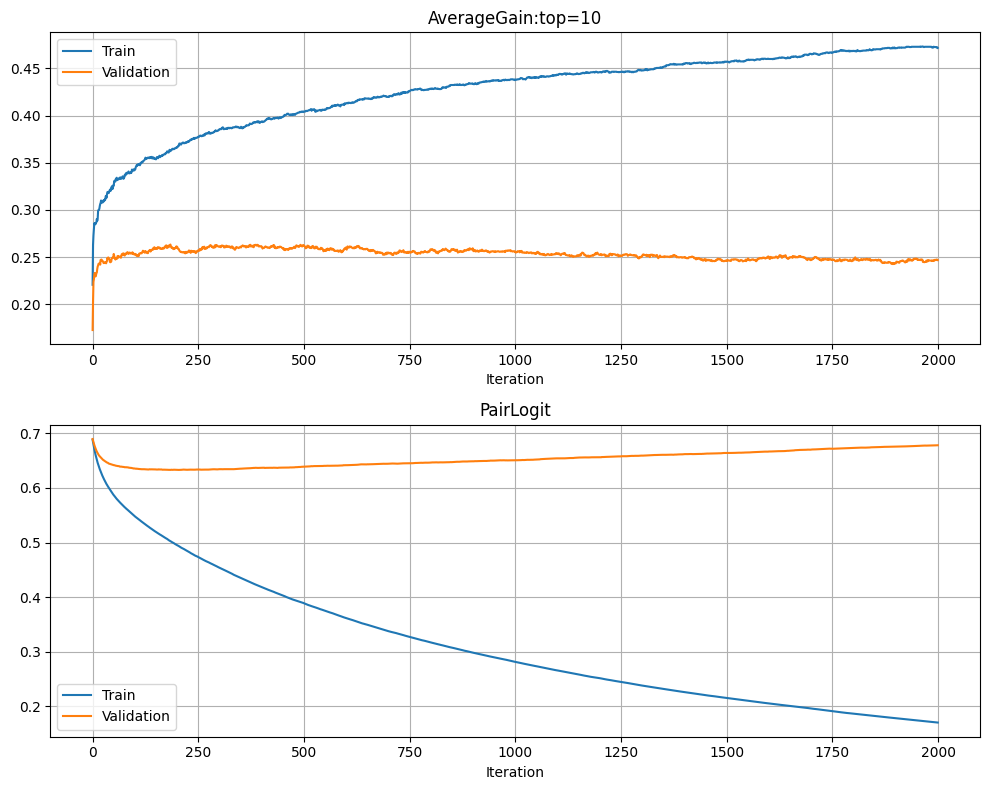

In [26]:
model_pairlogitpairwise = fit_model('PairLogitPairwise')
plot_metrics(model_pairlogitpairwise)

### Reducing problem, step 4

Previous loss function directly minimize the number of pairs $(d_i, d_j)$ where $l_i > l_j$ but $f(d_i) < f(d_j)$, simply said the number of incorrectly placed documents.

Since the user attention is high on the first documents and low on last the incorrect switch of the first two documents and last two has different cost.

In steps 3 and 3.1 user can set the weight for pair.

Method __YetiRank__ take this effect into account and generates weights for pairs according to their positions ([paper](https://cache-mskstoredata08.cdn.yandex.net/download.yandex.ru/company/to_rank_challenge_with_yetirank.pdf)).

$$ - \sum_{i,j \in Pairs} \color{red}{w_{ij}} \log \left( \frac{1}{1 + \exp{-(f(d_i) - f(d_j))}} \right) $$

0:	test: 0.5488205	best: 0.5488205 (0)	total: 55.3ms	remaining: 1m 50s
100:	test: 0.7000990	best: 0.7005962 (99)	total: 3.79s	remaining: 1m 11s
200:	test: 0.7017344	best: 0.7039641 (191)	total: 7.18s	remaining: 1m 4s
300:	test: 0.7005560	best: 0.7039641 (191)	total: 10.6s	remaining: 59.6s
400:	test: 0.6977235	best: 0.7039641 (191)	total: 13.6s	remaining: 54.3s
500:	test: 0.6958375	best: 0.7044291 (470)	total: 16.7s	remaining: 49.9s
600:	test: 0.6969230	best: 0.7044291 (470)	total: 20.2s	remaining: 47.1s
700:	test: 0.6970523	best: 0.7044291 (470)	total: 23.4s	remaining: 43.4s
800:	test: 0.6992067	best: 0.7044291 (470)	total: 26.9s	remaining: 40.2s
900:	test: 0.6988314	best: 0.7044291 (470)	total: 30.1s	remaining: 36.7s
1000:	test: 0.7019500	best: 0.7044291 (470)	total: 33.1s	remaining: 33.1s
1100:	test: 0.7013496	best: 0.7044291 (470)	total: 36.4s	remaining: 29.8s
1200:	test: 0.6998101	best: 0.7044291 (470)	total: 39.9s	remaining: 26.5s
1300:	test: 0.7002739	best: 0.7044291 (470)	total:

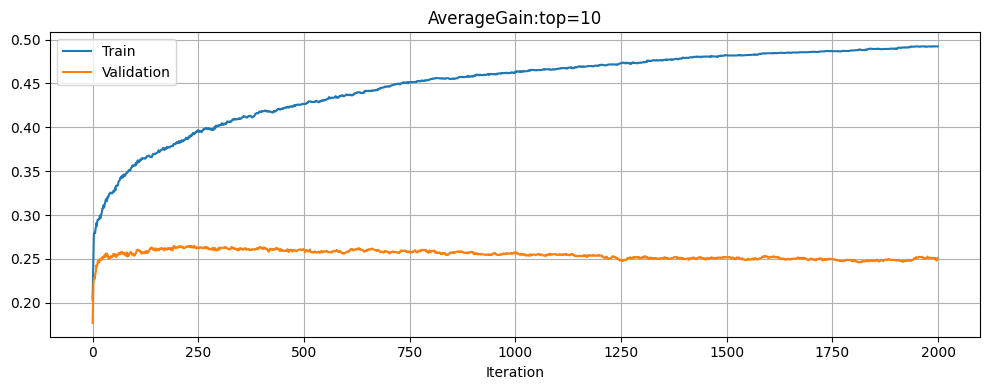

In [27]:
model_yetirank = fit_model('YetiRank')
plot_metrics(model_yetirank)

### Step 4.1

As in step 3.1 __YetiRankPairwise__ is slower than __YetiRank__, but gives more accurate results.

0:	test: 0.5219547	best: 0.5219547 (0)	total: 190ms	remaining: 6m 19s
100:	test: 0.6778837	best: 0.6791802 (96)	total: 17.7s	remaining: 5m 32s
200:	test: 0.6847438	best: 0.6866958 (198)	total: 34.2s	remaining: 5m 6s
300:	test: 0.6951225	best: 0.6951225 (300)	total: 50.3s	remaining: 4m 44s
400:	test: 0.6944683	best: 0.6973504 (365)	total: 1m 6s	remaining: 4m 24s
500:	test: 0.6928981	best: 0.6973504 (365)	total: 1m 21s	remaining: 4m 4s
600:	test: 0.6979275	best: 0.6984049 (594)	total: 1m 38s	remaining: 3m 49s
700:	test: 0.6992784	best: 0.6992784 (700)	total: 1m 53s	remaining: 3m 30s
800:	test: 0.6997404	best: 0.6999449 (797)	total: 2m 9s	remaining: 3m 13s
900:	test: 0.6991970	best: 0.7001906 (809)	total: 2m 25s	remaining: 2m 57s
1000:	test: 0.7010697	best: 0.7012388 (973)	total: 2m 40s	remaining: 2m 40s
1100:	test: 0.6997231	best: 0.7012388 (973)	total: 2m 56s	remaining: 2m 24s
1200:	test: 0.6983904	best: 0.7012388 (973)	total: 3m 12s	remaining: 2m 8s
1300:	test: 0.6983990	best: 0.701238

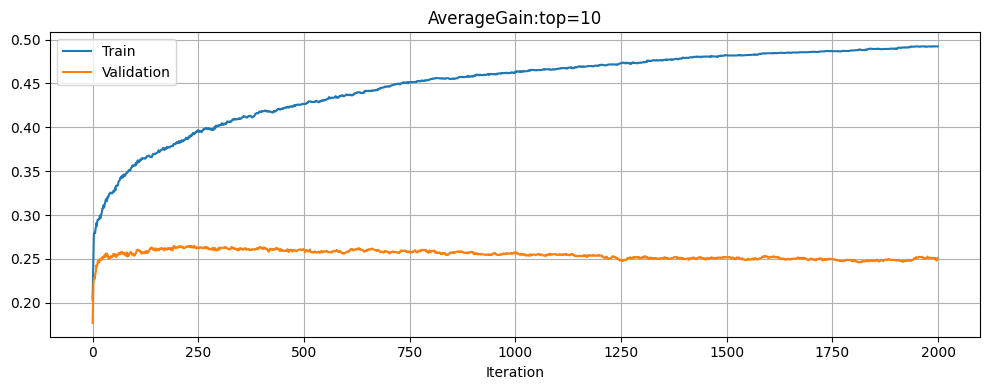

In [28]:
fit_model('YetiRankPairwise')
model_yetirank_pairwise = fit_model('YetiRank')
plot_metrics(model_yetirank_pairwise)

### Simple classification

Very fast $\rightarrow$ very slow; Simple method $\rightarrow$ complex method; Low quality $\rightarrow$ high quality.

1. RMSE
2. QueryRMSE
3. PairLogit
4. PairLogitPairwise
5. YetiRank
6. YetiRankPairwise

Besides our classification, the quality of the concrete method may depend on your dataset.

Look on NDCG metric of method YetiRank $-$ it's underfitted.

0:	test: 0.5488205	best: 0.5488205 (0)	total: 60.5ms	remaining: 2m
100:	test: 0.6841925	best: 0.7005624 (53)	total: 4.36s	remaining: 1m 21s
200:	test: 0.6724681	best: 0.7005624 (53)	total: 7.9s	remaining: 1m 10s
300:	test: 0.6663879	best: 0.7005624 (53)	total: 11s	remaining: 1m 2s
400:	test: 0.6532602	best: 0.7005624 (53)	total: 14s	remaining: 55.8s
500:	test: 0.6436623	best: 0.7005624 (53)	total: 17.1s	remaining: 51.1s
600:	test: 0.6534140	best: 0.7005624 (53)	total: 20.3s	remaining: 47.2s
700:	test: 0.6465826	best: 0.7005624 (53)	total: 23.2s	remaining: 42.9s
800:	test: 0.6429686	best: 0.7005624 (53)	total: 26s	remaining: 38.9s
900:	test: 0.6479391	best: 0.7005624 (53)	total: 28.8s	remaining: 35.2s
1000:	test: 0.6323748	best: 0.7005624 (53)	total: 31.7s	remaining: 31.6s
1100:	test: 0.6373098	best: 0.7005624 (53)	total: 34.4s	remaining: 28.1s
1200:	test: 0.6378066	best: 0.7005624 (53)	total: 37.3s	remaining: 24.8s
1300:	test: 0.6372641	best: 0.7005624 (53)	total: 40.1s	remaining: 21.5

Training has stopped (degenerate solution on iteration 1739, probably too small l2-regularization, try to increase it)



bestTest = 0.7005624482
bestIteration = 53

Shrink model to first 54 iterations.


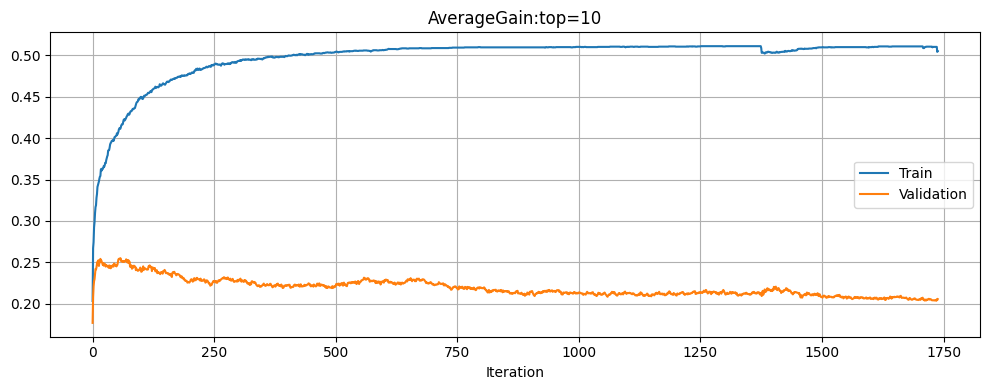

In [29]:
simple_classifier = fit_model('YetiRank', {'train_dir': 'YetiRank-lr-0.3', 'learning_rate': 0.3})
plot_metrics(simple_classifier)

In [30]:
## Well, it is vibecode. Watch full session: https://claude.ai/chat/a04cba31-07db-4504-8785-7e55fa7e431e

import matplotlib.gridspec as gridspec
from pathlib import Path

def load_catboost_metrics(train_dir: str) -> dict:
    """Load metrics from CatBoost training directory."""
    metrics = {}
    
    json_path = Path(train_dir) / 'test_error.tsv'
    learn_path = Path(train_dir) / 'learn_error.tsv'
    
    # Try JSON first (newer CatBoost versions)
    metapath = Path(train_dir) / 'time_left.tsv'
    
    def read_tsv(path):
        if not path.exists():
            return {}
        with open(path) as f:
            lines = f.read().strip().split('\n')
        if len(lines) < 2:
            return {}
        headers = lines[0].split('\t')
        data = {h: [] for h in headers}
        for line in lines[1:]:
            for h, v in zip(headers, line.split('\t')):
                try:
                    data[h].append(float(v))
                except ValueError:
                    pass
        return data
    
    learn_data = read_tsv(learn_path)
    test_data  = read_tsv(json_path)
    
    if learn_data:
        metrics['learn'] = {k: v for k, v in learn_data.items() if k != 'iter'}
        metrics['iter']  = learn_data.get('iter', list(range(len(next(iter(learn_data.values()))))))
    if test_data:
        metrics['validation'] = {k: v for k, v in test_data.items() if k != 'iter'}
        if 'iter' not in metrics:
            metrics['iter'] = test_data.get('iter', list(range(len(next(iter(test_data.values()))))))
    
    return metrics

def plot_catboost_runs(train_dirs: list, figsize_per_metric=(10, 3)):
    """
    Replacement for:
        MetricVisualizer(['RMSE', 'QueryRMSE', ...]).start()
        MetricVisualizer(['YetiRank', 'YetiRank-lr-0.3']).start()
    
    Parameters
    ----------
    train_dirs : list of str
        Same list you'd pass to MetricVisualizer.
    """

    all_data = {}
    for d in train_dirs:
        data = load_catboost_metrics(d)
        if data:
            all_data[d] = data
        else:
            print(f"⚠️  No metrics found in '{d}' — skipping.")
    
    if not all_data:
        print("No data to plot")
        return

    all_metric_names = set()
    for data in all_data.values():
        all_metric_names |= set(data.get('learn', {}).keys())
        all_metric_names |= set(data.get('validation', {}).keys())
    all_metric_names = sorted(all_metric_names)

    n_metrics = len(all_metric_names)
    fig, axes = plt.subplots(
        n_metrics, 1,
        figsize=(figsize_per_metric[0], figsize_per_metric[1] * n_metrics),
        squeeze=False
    )

    colors = plt.cm.tab10.colors
    
    for row, metric in enumerate(all_metric_names):
        ax = axes[row][0]
        for i, (run_name, data) in enumerate(all_data.items()):
            iters = data.get('iter', [])
            color = colors[i % len(colors)]
            
            if metric in data.get('learn', {}):
                ax.plot(iters, data['learn'][metric],
                        color=color, linestyle='-',
                        label=f'{run_name} — train', linewidth=1.5)
            if metric in data.get('validation', {}):
                ax.plot(iters, data['validation'][metric],
                        color=color, linestyle='--',
                        label=f'{run_name} — val', linewidth=1.5)
        
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_xlabel('Iteration')
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle('Key training metrics', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

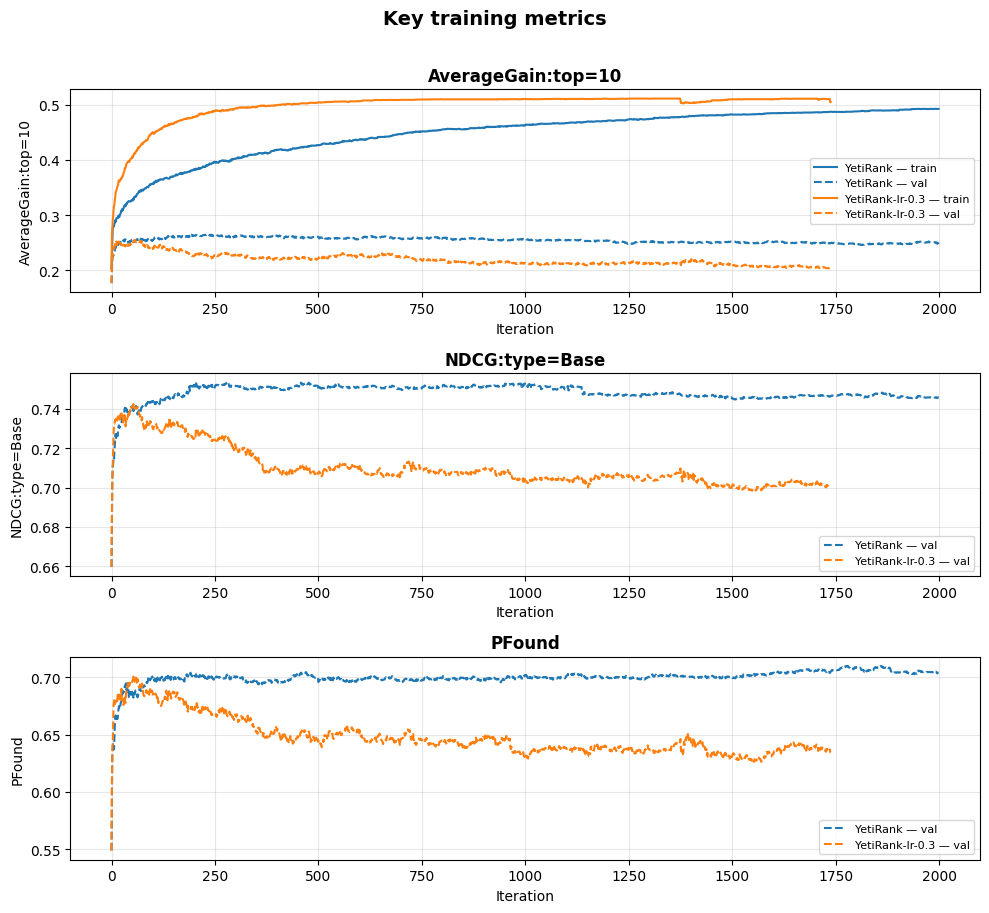

In [31]:
plot_catboost_runs(['YetiRank', 'YetiRank-lr-0.3'])

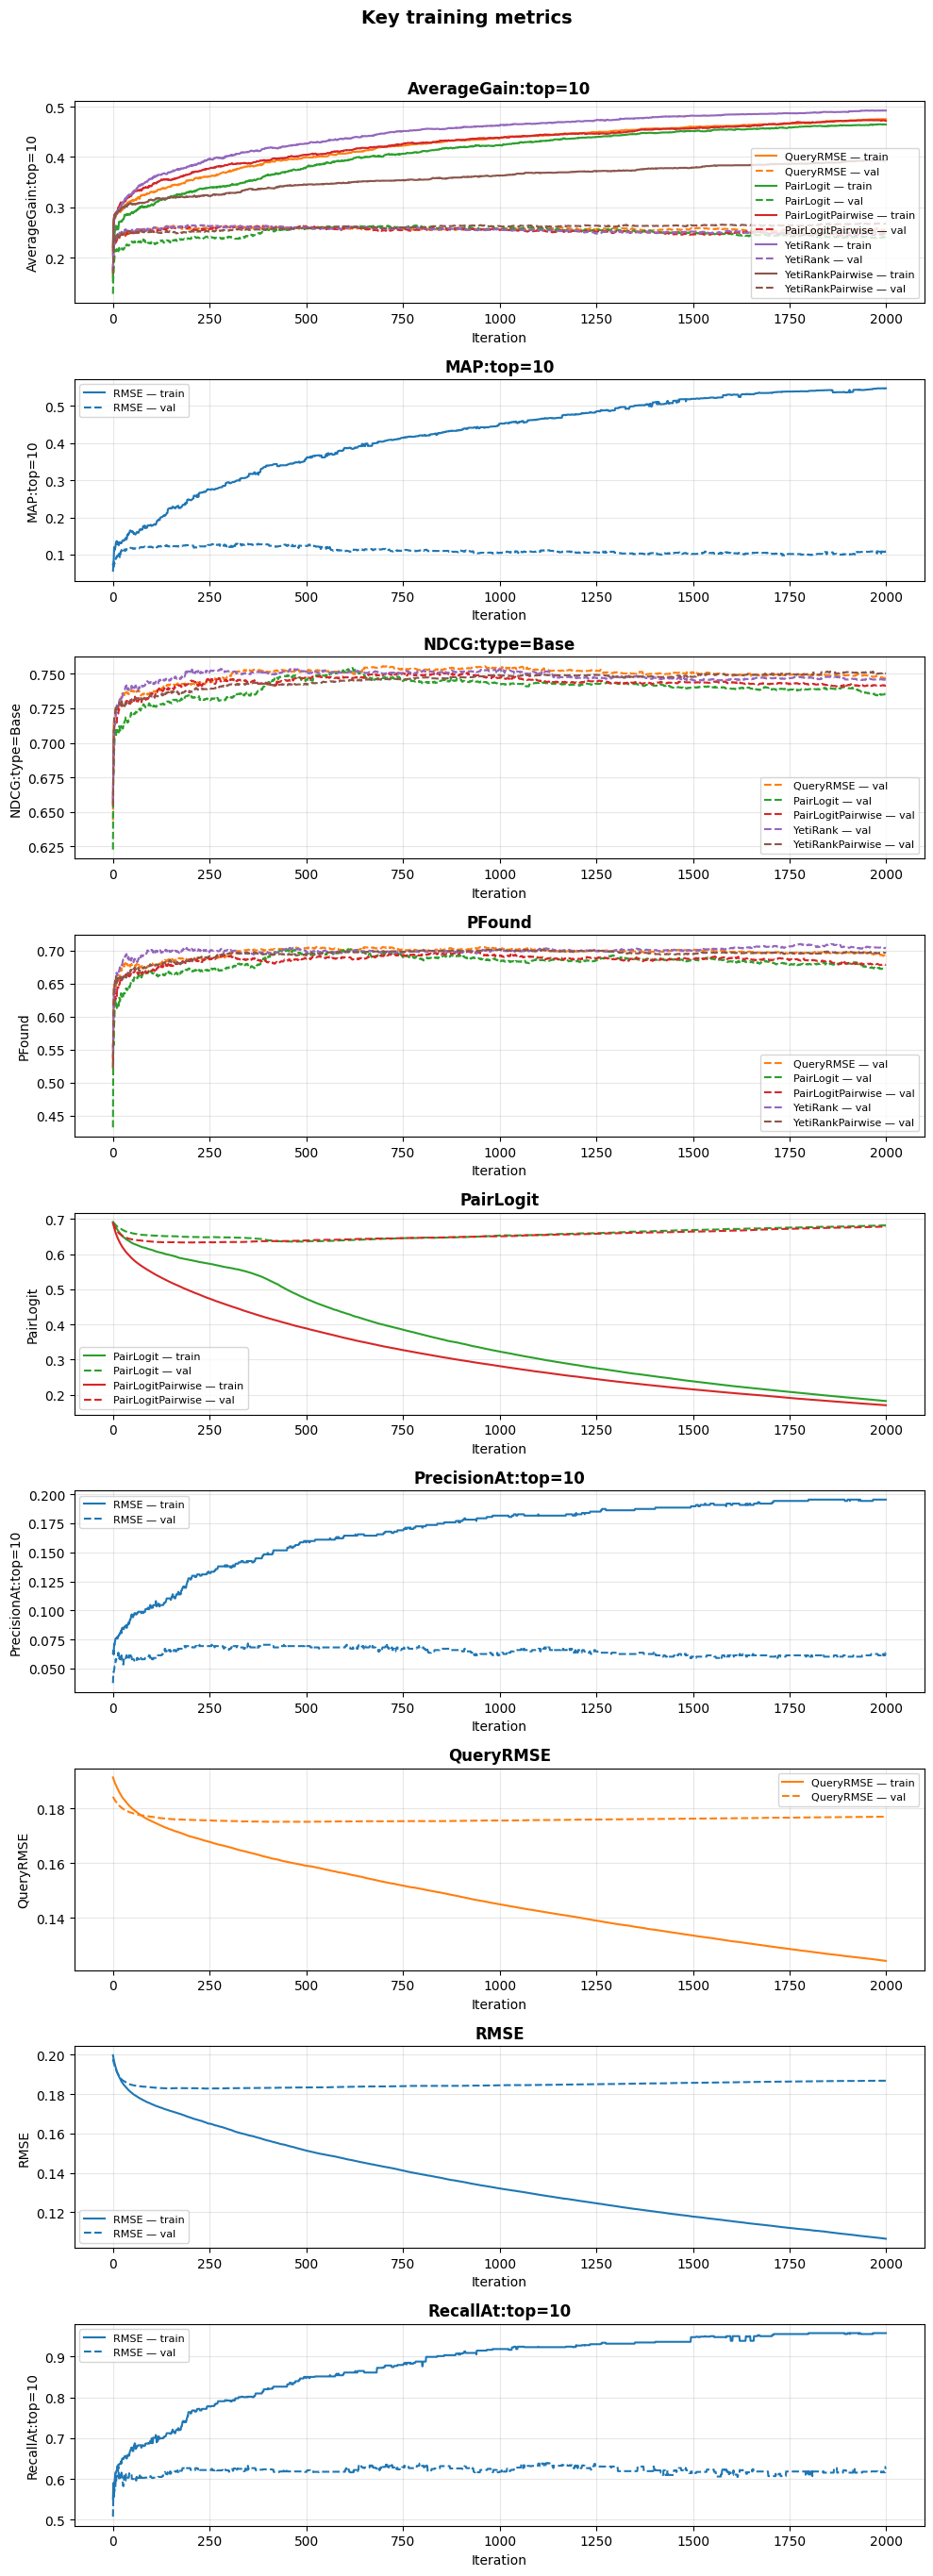

In [32]:
plot_catboost_runs(['RMSE', 'QueryRMSE', 'PairLogit', 'PairLogitPairwise', 'YetiRank', 'YetiRankPairwise'])

Вопреки заявленному, PairLogitPairwise работает заметно медленнее всех методов, включая YetiRankPairwise. (48 минут против 40 минут).

### Additional parameters

__Metric period__

Period in iterations of calculation metrics. This parameter can speed up training process.

In [33]:
fit_model('YetiRank', {'metric_period': 50})

0:	test: 0.5488205	best: 0.5488205 (0)	total: 36.7ms	remaining: 1m 13s
100:	test: 0.7000990	best: 0.7000990 (100)	total: 2.77s	remaining: 52s
200:	test: 0.7017344	best: 0.7017344 (200)	total: 5.36s	remaining: 48s
300:	test: 0.7005560	best: 0.7017344 (200)	total: 7.97s	remaining: 45s
400:	test: 0.6977235	best: 0.7017344 (200)	total: 10.6s	remaining: 42.2s
500:	test: 0.6958375	best: 0.7017344 (200)	total: 13.2s	remaining: 39.4s
600:	test: 0.6969230	best: 0.7017344 (200)	total: 15.8s	remaining: 36.9s
700:	test: 0.6970523	best: 0.7017344 (200)	total: 18.5s	remaining: 34.2s
800:	test: 0.6992067	best: 0.7017344 (200)	total: 21.1s	remaining: 31.6s
900:	test: 0.6988314	best: 0.7017344 (200)	total: 23.6s	remaining: 28.8s
1000:	test: 0.7019500	best: 0.7019500 (1000)	total: 26.3s	remaining: 26.3s
1100:	test: 0.7013496	best: 0.7019500 (1000)	total: 29s	remaining: 23.7s
1200:	test: 0.6998101	best: 0.7019500 (1000)	total: 31.6s	remaining: 21s
1300:	test: 0.7002739	best: 0.7019500 (1000)	total: 34.3s

CatBoostRanker(custom_metric=['NDCG', 'PFound', 'AverageGain:top=10'], iterations=2000, loss_function='YetiRank', metric_period=50, random_seed=0, train_dir='YetiRank', verbose=False)

__Task type__

You can significantly speed up training procedure by switching to GPU.

In [ ]:
# fit_model('YetiRank', {"'task_type': 'GPU'})

CatBoostError: catboost/cuda/cuda_lib/cuda_base.h:265: CUDA error 35: CUDA driver version is insufficient for CUDA runtime version

Не было доступной конфигурации GPU в тот момент, поэтому последний эксперимент не проводился.